# Exploratory Data Analysis: Retail Sales Data

**Objective:** This notebook performs an exploratory data analysis (EDA) on a global retail sales dataset (2011–2014, 51,290 orders across 21 fields) to identify sales trends, customer behavior patterns, and product/category performance, and to translate these findings into actionable business recommendations.

**Dataset:** Global Superstore sales data, sourced from Kaggle, containing order-level details including sales revenue, quantity, discount, profit, shipping cost, customer segment, geographic region, and product category.

**Approach:** The analysis proceeds through initial data inspection and cleaning, descriptive statistics, time series trend analysis, customer segment and regional breakdowns, product and category performance, and correlation analysis — concluding with a summary of key findings and recommendations.

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('SuperStoreOrders.csv')

In [4]:
df.shape

(51290, 21)

In [5]:
df['sales'] = df['sales'].astype(str).str.replace(',', '').str.replace('$', '', regex=False)
df['sales'] = df['sales'].astype(float)

In [6]:
df['order_date'] = pd.to_datetime(df['order_date'], format='mixed', dayfirst=True)
df['ship_date'] = pd.to_datetime(df['ship_date'], format='mixed', dayfirst=True)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  str           
 1   order_date      51290 non-null  datetime64[us]
 2   ship_date       51290 non-null  datetime64[us]
 3   ship_mode       51290 non-null  str           
 4   customer_name   51290 non-null  str           
 5   segment         51290 non-null  str           
 6   state           51290 non-null  str           
 7   country         51290 non-null  str           
 8   market          51290 non-null  str           
 9   region          51290 non-null  str           
 10  product_id      51290 non-null  str           
 11  category        51290 non-null  str           
 12  sub_category    51290 non-null  str           
 13  product_name    51290 non-null  str           
 14  sales           51290 non-null  float64       
 15  quantity     

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df['order_month'] = df['order_date'].dt.to_period('M')
monthly_sales = df.groupby('order_month')['sales'].sum()
monthly_sales

order_month
2011-01     98902.0
2011-02     91152.0
2011-03    145726.0
2011-04    116927.0
2011-05    146762.0
2011-06    215214.0
2011-07    115518.0
2011-08    207570.0
2011-09    290230.0
2011-10    199070.0
2011-11    298499.0
2011-12    333941.0
2012-01    135775.0
2012-02    100521.0
2012-03    163092.0
2012-04    161060.0
2012-05    208370.0
2012-06    256181.0
2012-07    145247.0
2012-08    303158.0
2012-09    289390.0
2012-10    252942.0
2012-11    323512.0
2012-12    338245.0
2013-01    199197.0
2013-02    167247.0
2013-03    198591.0
2013-04    177835.0
2013-05    260525.0
2013-06    396513.0
2013-07    229940.0
2013-08    326491.0
2013-09    376626.0
2013-10    293423.0
2013-11    373996.0
2013-12    405476.0
2014-01    241267.0
2014-02    184848.0
2014-03    263110.0
2014-04    242781.0
2014-05    288404.0
2014-06    401843.0
2014-07    258718.0
2014-08    456633.0
2014-09    481186.0
2014-10    422785.0
2014-11    555312.0
2014-12    503154.0
Freq: M, Name: sales, dtype:

Monthly Sales Trend Observations
Sales show consistent year-over-year growth from 2011 to 2014. There is a strong seasonal pattern: November and December are consistently the highest-selling months each year (likely holiday season demand), while January and February are consistently the lowest, suggesting a post-holiday slowdown.

In [10]:
df['order_quarter'] = df['order_date'].dt.to_period('Q')
quarterly_sales = df.groupby('order_quarter')['sales'].sum()
quarterly_sales

order_quarter
2011Q1     335780.0
2011Q2     478903.0
2011Q3     613318.0
2011Q4     831510.0
2012Q1     399388.0
2012Q2     625611.0
2012Q3     737795.0
2012Q4     914699.0
2013Q1     565035.0
2013Q2     834873.0
2013Q3     933057.0
2013Q4    1072895.0
2014Q1     689225.0
2014Q2     933028.0
2014Q3    1196537.0
2014Q4    1481251.0
Freq: Q-DEC, Name: sales, dtype: float64

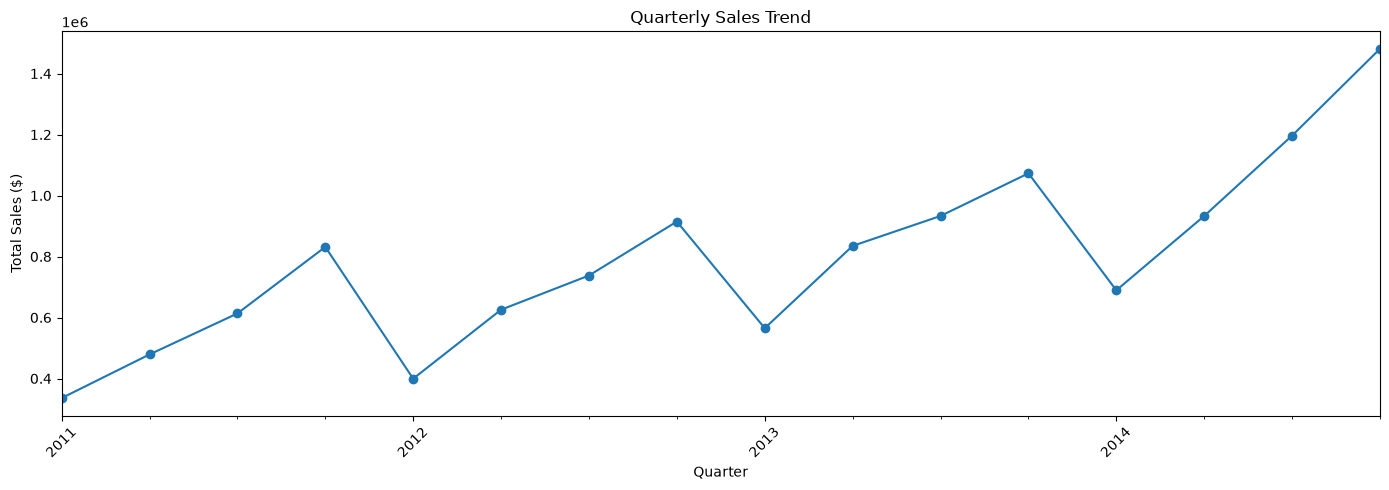

In [11]:
plt.figure(figsize=(14, 5))
quarterly_sales.plot(kind='line', marker='o')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Quarterly Sales Trend Observations
The quarterly view confirms the seasonal pattern seen in the monthly data: Q4 (Oct-Dec) is consistently the strongest quarter each year, while Q1 (Jan-Mar) is consistently the weakest. Despite this recurring dip, each year's Q1 outperforms the previous year's Q1, confirming steady overall business growth from 2011 to 2014.

In [12]:
df.columns.tolist()

['order_id',
 'order_date',
 'ship_date',
 'ship_mode',
 'customer_name',
 'segment',
 'state',
 'country',
 'market',
 'region',
 'product_id',
 'category',
 'sub_category',
 'product_name',
 'sales',
 'quantity',
 'discount',
 'profit',
 'shipping_cost',
 'order_priority',
 'year',
 'order_month',
 'order_quarter']

segment_counts = df['segment'].value_counts()
segment_counts

In [13]:
plt.figure(figsize=(8, 5))
segment_counts.plot(kind='bar', color='steelblue')
plt.title('Orders by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

NameError: name 'segment_counts' is not defined

<Figure size 800x500 with 0 Axes>

In [ ]:
segment_sales = df.groupby('segment')['sales'].sum().sort_values(ascending=False)
segment_sales

Customer Segment Observations
The Consumer segment generates the most total revenue ($6.51M) and has by far the highest order count (26,518), while Corporate ($3.82M, 15,429 orders) and Home Office ($2.31M, 9,343 orders) trail behind. However, average order value is nearly identical across all three segments (~$245-248), showing that Consumer's revenue lead comes from order volume, not higher per-order spending — a useful distinction for targeting strategy.

In [ ]:
region_sales = df.groupby('region')['sales'].sum().sort_values(ascending=False)
region_sales

Regional Sales Observations
The Central region generates by far the most revenue ($2.82M), roughly 76% more than the second-highest region (South, $1.60M). Revenue drops off sharply toward smaller regions like Caribbean and Canada, with Canada generating the least by a wide margin ($67K) — a potential area to investigate further (e.g., market size, distribution reach, or expansion opportunity).

In [ ]:
top_products = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)
top_products

In [ ]:
plt.figure(figsize=(10, 6))
top_products.sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Best-Selling Products by Revenue')
plt.xlabel('Total Sales ($)')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

In [ ]:
category_sales = df.groupby('category')['sales'].sum().sort_values(ascending=False)
category_sales

In [ ]:
plt.figure(figsize=(8, 5))
category_sales.plot(kind='bar', color='coral')
plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Product & Category Observations
The top 10 best-selling products are dominated by two product types across multiple brands: smartphones (6 of 10 entries) and executive leather office chairs (3 of 10 entries), suggesting these are strong-performing product categories rather than isolated hits. This is confirmed at the category level: Technology leads overall revenue ($4.74M), closely followed by Furniture ($4.11M) and Office Supplies ($3.79M) — all three categories contribute fairly evenly, with no single category dominating the business.

In [ ]:
numeric_cols = ['sales', 'quantity', 'discount', 'profit', 'shipping_cost']
corr_matrix = df[numeric_cols].corr()
corr_matrix

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

Correlation Heatmap Observations
Sales and shipping cost show the strongest relationship (0.77), indicating larger orders tend to have higher shipping costs. Sales and profit are moderately correlated (0.49). Most notably, discount and profit show a moderate negative correlation (-0.32), confirming that higher discounts are associated with lower profitability — this supports the earlier finding of significantly negative-profit orders and suggests discounting practices are a meaningful factor worth reviewing.

In [14]:
category_discount_profit = df.groupby('category')[['discount', 'profit']].mean()
category_discount_profit

,discount,profit
category,,
Furniture,0.168087,29.038300
Office Supplies,0.137409,16.578961
Technology,0.135342,65.454958


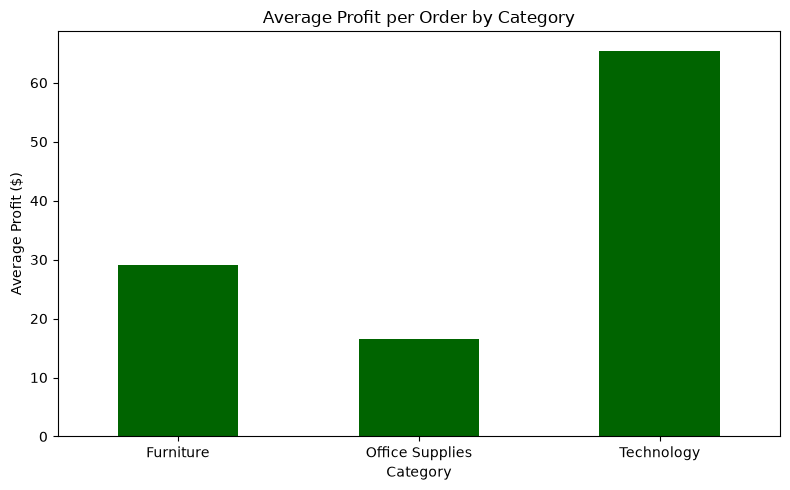

In [15]:
plt.figure(figsize=(8, 5))
category_discount_profit['profit'].plot(kind='bar', color='darkgreen')
plt.title('Average Profit per Order by Category')
plt.xlabel('Category')
plt.ylabel('Average Profit ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Non-Obvious Insight: Discount vs. Profitability by Category
Furniture receives the highest average discount (16.8%) of any category, yet earns the second-lowest average profit per order ($29.04) — despite being a top-revenue category. Technology, by contrast, receives the lightest discounting (13.5%) and earns by far the highest average profit per order ($65.45). This suggests Furniture's heavy discounting may be substantially suppressing profitability that its strong revenue performance would otherwise support — a strong candidate for a pricing/discount policy review.

In [ ]:
## Conclusion & Business Recommendations

This analysis examined 51,290 retail orders spanning 2011–2014 across customer segments, regions, product categories, and time. Below is a summary of key findings and actionable recommendations based on the data.

### Key Findings
- **Consistent growth**: Revenue grew year-over-year from 2011 to 2014, with a strong seasonal pattern — Q4 (Oct–Dec) is consistently the strongest period, while Q1 (Jan–Mar) is consistently the weakest.
- **Consumer segment leads on volume, not value**: The Consumer segment drives the most total revenue, but this is due to a higher number of orders — average order value is nearly identical (~$245–248) across Consumer, Corporate, and Home Office segments.
- **Central region is the strongest market**, generating significantly more revenue than any other region, while regions like Canada remain minimal contributors.
- **Discounting hurts profitability**: Higher discounts are moderately correlated with lower profit (-0.32). Furniture is the most heavily discounted category (16.8% average) and earns the lowest average profit per order relative to its revenue, while Technology — the least discounted category — earns the highest average profit per order.

### Recommendations

**1. Reassess Furniture's discounting strategy.**
Furniture generates strong revenue but is undermined by heavy average discounting (16.8%), resulting in comparatively weak per-order profit. Reducing discount depth on Furniture — or restricting deep discounts to slow-moving inventory only — could meaningfully improve profitability without necessarily sacrificing revenue.

**2. Prepare inventory and staffing for the Q4 seasonal surge.**
Sales consistently peak in November and December each year. The business should ensure adequate stock levels, supplier lead times, and staffing are planned ahead of Q4, while using the reliably slower Q1 period for inventory clearance, planning, or lower-cost marketing experiments.

**3. Investigate underperforming regions, starting with Canada.**
Canada generates substantially less revenue than every other region, including markets of comparable or smaller apparent scale. A focused review — pricing, product availability, marketing reach, or distribution — could reveal a low-cost expansion opportunity.

**4. Protect and grow the Technology category.**
Technology is the most profitable category per order and receives the lightest discounting, indicating healthy underlying demand. Prioritizing marketing spend and inventory investment here is likely to yield strong returns compared to categories requiring heavier discounts to move.